# Week 5 Day 3 Lab

### Problem 1
*Gradient descent* on a function $f(x)$ in the two dimensional case works as follows:
1. Start with an initial value $x_0$.
2. Compute $f'(x_0)$.
3. 
    - If $f'(x_0)>0$, move to $x_0-\epsilon$. 
    - If $f'(x_0)<0$, move to $x_0+\epsilon$. 
    - If $f'(x_0)=0$, stay put.
4. Repeat steps 1-3 for a certain amount of iterations.

Create a function that performs gradient descent. Be careful: your function should take in an iteration number so it does not run forever.

-0.834999999999983


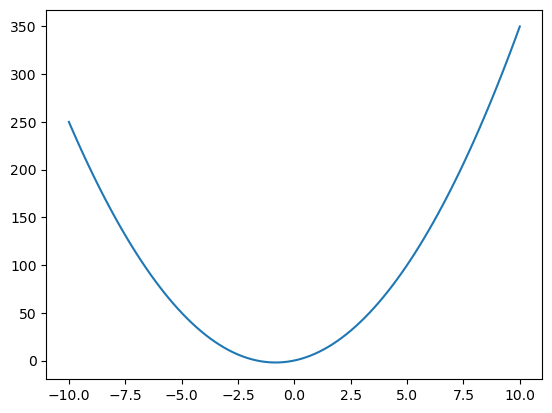

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
import sympy as sp
x = sp.Symbol('x')

def gradient(func, x0, epsilon, iterations):
    f_prime = sp.diff(func, x)
    X = x0
    for _ in range(iterations):
        derivative = f_prime.subs(x,X)
        if derivative > 0:
            X = X - epsilon
        elif derivative < 0:
            X = X + epsilon
        else:
            break
    return X
print(gradient(3*x**2 + 5*x, 1, 0.0025, 1000))



i = np.linspace(-10,10,100)
f = 3*i**2 + 5*i
plt.plot(i,f)

### Problem 2
Your function from above should be able to find minima. Use `%timeit` to compare the run time of your function and `minimize` from the `scipy.optimize` library. Rerun for multiple different starting points.

In [26]:
%timeit print(gradient(3*x**2 + 5*x, 1, 0.0025, 1000))
def objective(x):
    return 3*x**2 + 5*x
%timeit minimize(objective, 0)

-0.834999999999983
-0.834999999999983
-0.834999999999983
-0.834999999999983
-0.834999999999983
-0.834999999999983
-0.834999999999983
-0.834999999999983
617 ms ± 35.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.01 ms ± 93.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Problem 3
Use `%timeit` to determine the speed of fitting a regression line by minimizing the sum of squared errors. Likewise, use `%timeit` to on using `np.polyfit()`. Was there a difference in speed?

In [33]:
x = np.linspace(-5, 5, 100)
y = 2.5 *x + 4*np.random.uniform(-1, 1, 100)
def loss(params):
    a,b = params
    prediction = a*x+b
    return np.sum((y-prediction)**2)
%timeit minimize(loss,[0,0])
%timeit np.polyfit(x, y, 1)

6.96 ms ± 335 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
163 μs ± 21.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
# Minimize is so much slower because it has to iterate

### Problem 4 
The `loss()` function from lecture uses SSE as its error function. Define a new function `loss_2()` using a different error function. Plot the resulting lines for `loss()` and `loss_2()` on an example dataset.

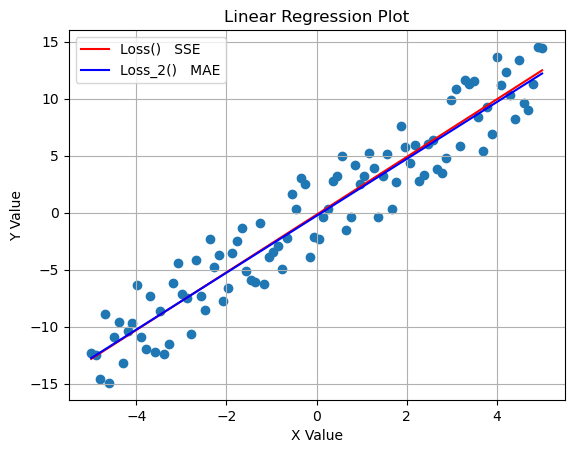

In [36]:
x = np.linspace(-5, 5, 100)
y = 2.5 *x + 4*np.random.uniform(-1, 1, 100)

def loss(params):
    a,b = params
    prediction = a*x+b
    return np.sum((y - prediction)**2)
result = minimize(loss, [0,0])

def loss_2(params):
    a,b = params
    prediction = a*x+b
    return np.sum(np.abs(y- prediction))
result_2 = minimize(loss_2, [0,0])

a,b = result.x
c,d = result_2.x
plt.scatter(x,y)
plt.plot(x, a*x+b, color='red', label= 'Loss()   SSE')
plt.plot(x, c*x+d, color='blue', label= 'Loss_2()   MAE')
plt.xlabel('X Value')
plt.ylabel('Y Value')
plt.title('Linear Regression Plot')
plt.legend()
plt.grid(True)
plt.show()